# Import

In [74]:
import ast
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd
from scipy.stats import zscore
from scipy.stats import zscore
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 16,           # Global font size
    'axes.titlesize': 24,      # Title font size
    'axes.labelsize': 24,      # X and Y label font size
    'xtick.labelsize': 16,     # X tick label font size
    'ytick.labelsize': 16,     # Y tick label font size
})

# Importing specific functions from the module
from func_preprocessing import restructure_dataset, remove_outliers, smooth
from func_indecies import ndvi, nbr, ndwi, ndre, tcw, tcg, tcb, ndmi, nirv, kndvi, drs, ndrs, kdrs, kndrs
from func_helper import parse_custom_colors, format_label
from func_file_io import load_data

# Functions

In [88]:
def load_netcdf(filepath):
    """Load a NetCDF file using xarray."""
    if os.path.exists(filepath):
        return xr.open_dataset(filepath)
    else:
        print(f"File {filepath} not found.")
        return None


In [78]:
import matplotlib.pyplot as plt

def plot_by_index(s1dm_gdf, ids_gdf, index):
    """
    This function takes an index, retrieves the corresponding IDX_D from s1dm_gdf,
    and then plots the geometries from both s1dm_gdf and ids_gdf based on the IDX_D.

    Parameters:
    - s1dm_gdf (GeoDataFrame): The GeoDataFrame containing S1DM data.
    - ids_gdf (GeoDataFrame): The GeoDataFrame containing IDS data.
    - index (int): The row index from s1dm_gdf to retrieve the corresponding IDX_D.
    
    Returns:
    - None (shows the plot)
    """
    
    # Get the IDX_D from the given row in s1dm_gdf
    idx_d = s1dm_gdf.iloc[index]['IDX_D']
    
    # Filter the geometries corresponding to the IDX_D from both gdfs
    s1dm_geom = s1dm_gdf[s1dm_gdf['IDX_D'] == idx_d]
    ids_geom = ids_gdf[ids_gdf['IDX_D'] == idx_d]
    
    # Check if both geometries are found
    if s1dm_geom.empty:
        print(f"No geometry found for IDX_D {idx_d} in s1dm_gdf.")
        return
    if ids_geom.empty:
        print(f"No geometry found for IDX_D {idx_d} in ids_gdf.")
        return

    # Create a figure and axis for plotting
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the boundary of s1dm_geom in blue
    s1dm_geom.boundary.plot(ax=ax, color='blue', label='S1DM Geometry')
    
    # Plot the boundary of ids_geom in red
    ids_geom.boundary.plot(ax=ax, color='red', label='IDS Geometry')
    
    # Add a legend
    plt.legend()
    
    # Add a title
    ax.set_title(f"IDX_D {idx_d} Geometries (From Index {index})")
    
    # Show the plot
    plt.show()

In [75]:
def add_minicube_index(intersected_grid, ids):

    # Function to get intersecting indices
    def get_intersecting_indices(geometry, grid):
        intersecting_indices = grid[grid.intersects(geometry)].index.tolist()
        return intersecting_indices

    # Apply the function to each row in reprojected_refdm
    ids['minicube_index'] = ids['geometry'].apply(lambda geom: get_intersecting_indices(geom, intersected_grid))

    # Add the 'cube_amount' column by counting the length of each list in 'minicube_index'
    ids['cube_amount'] = ids['minicube_index'].apply(len)

    return ids

In [76]:
def extract_unique_minicubes(refdm_filtered, ids_filtered, intersected_grid):
    def convert_to_list(value):
        """Convert string representation of list to an actual list or return value directly."""
        try:
            return ast.literal_eval(value) if isinstance(value, str) else value
        except (ValueError, SyntaxError):
            return []

    # Extract and flatten minicube values for refdm
    minicube_refdm = [
        int(item)
        for sublist in [convert_to_list(val) for val in refdm_filtered['mini_idx'].values]
        for item in sublist
    ]

    # print(f"REFDM: {minicube_refdm}")
    
    # Extract and flatten minicube values for ids
    minicube_ids = [
        int(item)
        for sublist in [convert_to_list(val) for val in ids_filtered['mini_idx'].values]
        for item in sublist
    ]
    # print(f"IDS: {minicube_ids}")

    # Combine both lists and get unique values
    unique_minicubes = list(set(minicube_refdm + minicube_ids))

    # Use .isin() to filter when unique_minicubes is a list
    grid = intersected_grid.loc[intersected_grid['FID'].isin(unique_minicubes)]

    return unique_minicubes, grid


# Preperations

In [77]:
# Load environment variables from the .env file
#env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env_IEF')
env_path = Path('/work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

# Retrieve environment variables
grid_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {grid_folder}")

# Check if the folder exists
if not os.path.isdir(grid_folder):
    raise FileNotFoundError(f"The folder {grid_folder} does not exist.")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512


ids_path = f"{os.getenv('RESULTS')}/region_{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
path_grid = f"{grid_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}.shp"
path_conves = f"{os.getenv('RESULTS')}/radar_results/convex_hulls_refdm_region_{region_id}_epsg_4326.shp"
path_intersetion_grid = f"{grid_folder}/intersected_grid_{resolution}_{pixel_size}_region_{region_id}.shp"


figure_output_path = f"{os.getenv('FIGURES')}"
if not os.path.exists(figure_output_path):
        os.makedirs(figure_output_path)
        

s2_minicube_folder = os.getenv('SENTINEL2_CUBES_PP')
print(f"Sentinel 2 NetCDF folder: {s2_minicube_folder}")

print("Load the Forest Disturbances ...")
s1dm_gdf = load_data(refdm_path)
ids_gdf = load_data(ids_path)
grid_gdf = load_data(path_intersetion_grid)

Equi7 grids folder: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/grids/
Sentinel 2 NetCDF folder: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/Data/S2_Minicubes_IDS_R8_Preprocessed/
Load the Forest Disturbances ...
Loading shapefile from: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/results_clean//radar_enhanced_forest_disturbance_mapping_region_08.shp
Loading shapefile from: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/results_clean//region_08_dca_filtered_ids_usda_polygons.shp
Loading shapefile from: /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/grids//intersected_grid_10_512_region_08.shp


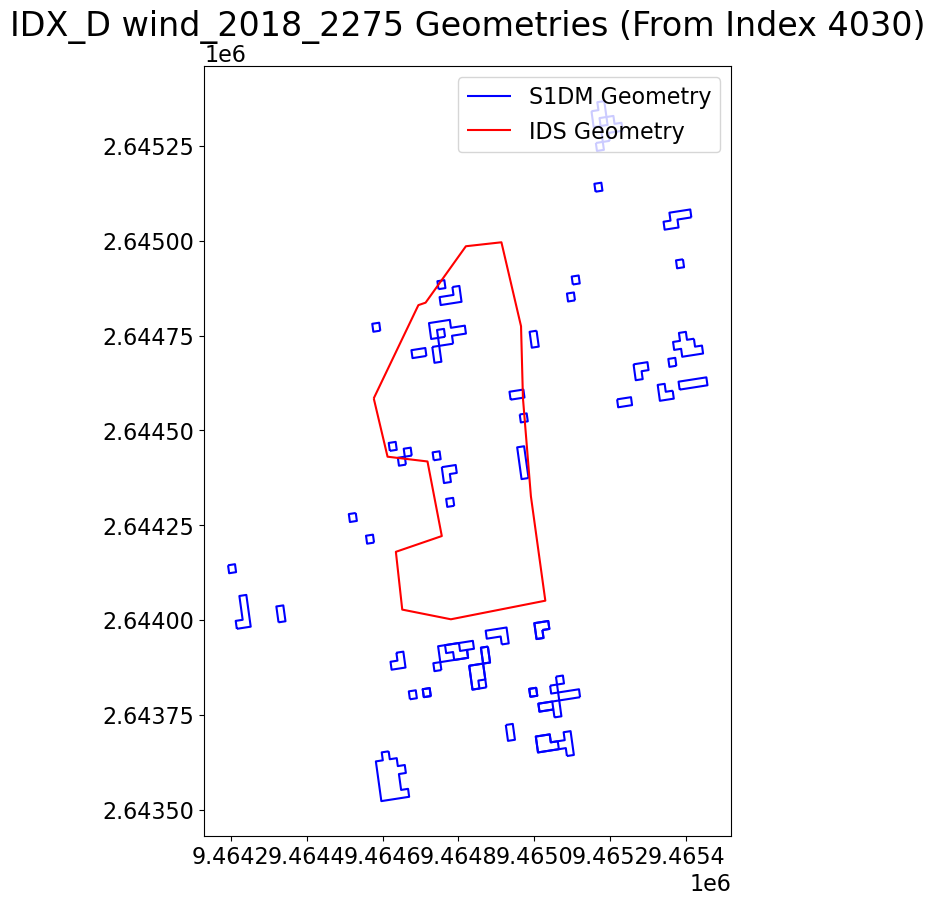

In [79]:
plot_by_index(s1dm_gdf, ids_gdf, 4030)

In [80]:
# Drop the 'IDX_D_left' column
grid_gdf

,FID,geometry
0,0,"POLYGON ((8448000 2908160, 8442880 2908160, 84..."
1,1,"POLYGON ((8453120 2882560, 8448000 2882560, 84..."
2,2,"POLYGON ((8453120 2908160, 8448000 2908160, 84..."
3,3,"POLYGON ((8458240 2892800, 8453120 2892800, 84..."
4,4,"POLYGON ((8458240 2897920, 8453120 2897920, 84..."
...,...,...
1045,1045,"POLYGON ((10168320 3205120, 10163200 3205120, ..."
1046,1046,"POLYGON ((10168320 3210240, 10163200 3210240, ..."
1047,1047,"POLYGON ((10173440 3205120, 10168320 3205120, ..."
1048,1048,"POLYGON ((10173440 3210240, 10168320 3210240, ..."


In [82]:
s1dm_gdf

,IDX_D,S1_YEAR,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_E,...,O_DCA_ID,O_Y_diff,area_km2,area_right,area,minicube_i,cube_amoun,minicube_1,cube_amo_1,geometry
0,bark_beetle_2016_0,2016,E087N024T3,0.002669,0,bark_beetle,2016,8,1,23857,...,None,NaN,0.015911,1.295255,0.002669,[349],1,[349],1,"MULTIPOLYGON (((8879435.234 2589801.253, 88794..."
1,bark_beetle_2016_1,2016,E093N030T3,0.000578,1,bark_beetle,2016,8,1,23858,...,None,NaN,0.010146,1.243389,0.000578,[833],1,[833],1,"MULTIPOLYGON (((9525194.278 3138117.285, 95252..."
2,bark_beetle_2016_12,2016,E090N027T3,0.003326,12,bark_beetle,2016,8,1,23874,...,None,NaN,0.043778,1.104247,0.003326,"[706, 707]",2,"[706, 707]",2,"MULTIPOLYGON (((9231040.936 2808548.256, 92310..."
3,bark_beetle_2016_47,2016,E084N027T3,0.013320,47,bark_beetle,2016,8,1,23944,...,None,NaN,0.011143,2.822145,0.013320,[47],1,[47],1,"MULTIPOLYGON (((8613233.253 2939162.959, 86132..."
4,bark_beetle_2016_8,2016,E090N027T3,0.019959,8,bark_beetle,2016,8,1,23866,...,None,NaN,0.014324,1.443711,0.019959,[706],1,[706],1,"POLYGON ((9231021.578 2810803.837, 9231058.228..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5610,wind_2020_2048,2021,E084N024T3,0.000533,2048,wind,2020,8,16,26829,...,None,NaN,0.035249,10.208057,0.000533,"[67, 68]",2,"[67, 68]",2,"MULTIPOLYGON (((8642744.896 2471122.259, 86427..."
5611,wind_2020_2055,2018,E090N030T3,0.000594,2055,wind,2020,8,16,26846,...,None,NaN,0.130823,38.236496,0.000594,"[665, 668, 670, 675, 680, 682]",6,"[665, 668, 670, 675, 680, 682]",6,"MULTIPOLYGON (((9081625.523 3145059.856, 90816..."
5612,wind_2020_2055,2019,E090N030T3,0.000594,2055,wind,2020,8,16,26846,...,None,NaN,0.064821,38.236496,0.000594,"[665, 668, 670, 675, 680, 682]",6,"[665, 668, 670, 675, 680, 682]",6,"MULTIPOLYGON (((9081275.489 3144953.529, 90812..."
5613,wind_2020_2055,2020,E090N030T3,0.000594,2055,wind,2020,8,16,26846,...,None,NaN,0.198790,38.236496,0.000594,"[665, 668, 670, 675, 682]",5,"[665, 668, 670, 675, 682]",5,"MULTIPOLYGON (((9083880.467 3145429.862, 90838..."


In [89]:
i = 0
path = f"{s2_minicube_folder}/{i}_10_512_20152024_equi7_NA.nc"
mc = load_netcdf(path)
mc

File /work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/Data/S2_Minicubes_IDS_R8_Preprocessed//0_10_512_20152024_equi7_NA.nc not found.


In [ ]:
def calculate_timeseries_events(ids,s1dm,cubes):

    # load s1dm
    #s1dm
    # load ids
    #ids
    # Iterate over Minicubes
    for cube in cubes:
        i = cube['FDI']
        # load minicubes
        path = f"{s2_minicube_folder}/{i}_10_512_20152024_equi7_NA.nc"
        if os.path.exists(path):
            mc =  xr.open_dataset(path)
        else:
            print(f"File {filepath} not found.")
        
        # select subset of s1dm events that are  on this minicube event
            # for each event
            # select relevant s1dm pixels 
            # select relevant ids pixels
            # calculate reference season
            # calculate differnece 
            # take spatial mean
            # normalize on disturbance year 

            # check if file for this event exists
                 # - yes: load file , add pixel amount , merge (Mean wigth on pixel amount), save
                 # - no : create file, add pixel amount, save


    
# go through all files with nbr timseseries, and plot them 